# HMM Bias Comparison

In [7]:
# Whether to recompute results
#RERUN = false
RERUN = true

true

In [8]:
using StatsPlots, StatsPlots.PlotMeasures
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl")

subject_cov (generic function with 1 method)

In [9]:
fns_hmm = [
    ("hmm_leaf", run_hmm_leaf),
    ("hmm_leaf_γ2", run_hmm_leaf_γ2),
    ("hmm_leaf_retainbelief", run_hmm_leaf_retainbelief),
    ("hmm_leaf_stay", run_hmm_leaf_stay),
    ("hmm_leaf_turn", run_hmm_leaf_turn),
    ("hmm_leaf_spatial", run_hmm_leaf_spatial),
    ("hmm_leaf_leafturn", run_hmm_leaf_leafturn),
    ("hmm_leaf_leafspatial", run_hmm_leaf_leafspatial),
]
fns_hmm_stay = [
    ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2),
    ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief),
    ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial),
    ("hmm_leaf_stay_leafturn", run_hmm_leaf_stay_leafturn),
    ("hmm_leaf_stay_leafspatial", run_hmm_leaf_stay_leafspatial),
    ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn),
    ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial),
    ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn),
    ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial),    
    ]
fns_hmm_γ2 = [
    ("hmm_leaf_turn_γ2", run_hmm_leaf_turn_γ2),
    ("hmm_leaf_spatial_γ2", run_hmm_leaf_spatial_γ2),
    ("hmm_leaf_turn_leafturn_γ2", run_hmm_leaf_turn_leafturn_γ2),
    ("hmm_leaf_turn_leafspatial_γ2", run_hmm_leaf_turn_leafspatial_γ2),
    ("hmm_leaf_spatial_leafturn_γ2", run_hmm_leaf_spatial_leafturn_γ2),
    ("hmm_leaf_spatial_leafspatial_γ2", run_hmm_leaf_spatial_leafspatial_γ2),
    ]
fns_hmm_stay_γ2 = [
    ("hmm_leaf_stay_turn_γ2", run_hmm_leaf_stay_turn_γ2),
    ("hmm_leaf_stay_spatial_γ2", run_hmm_leaf_stay_spatial_γ2),
    ("hmm_leaf_stay_turn_leafturn_γ2", run_hmm_leaf_stay_turn_leafturn_γ2),
    ("hmm_leaf_stay_turn_leafspatial_γ2", run_hmm_leaf_stay_turn_leafspatial_γ2),
    ("hmm_leaf_stay_spatial_leafturn_γ2", run_hmm_leaf_stay_spatial_leafturn_γ2),
    ("hmm_leaf_stay_spatial_leafspatial_γ2", run_hmm_leaf_stay_spatial_leafspatial_γ2),
    ]
fns = vcat(fns_hmm, fns_hmm_stay, fns_hmm_γ2, fns_hmm_stay_γ2);
# fns = fns_leaf

In [10]:
if RERUN
    for animal in animals
        for (fname, fn) in fns #AC changed for ... in fns_leafbias to for ... in fns
            results = fn(load_animal(animal, filepath))
            save("$(filepath)/results/hmm_biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)", results)
        end
    end
end

In [11]:
function load_hmm_results(animals, fns; rewscaled=true)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    if rewscaled
        add_rewscaled = "_rewscaled"
    else
        add_rewscaled = ""
    end
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/hmm_biases/$(fname)$(add_rewscaled)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)$(add_rewscaled)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_hmm_results (generic function with 1 method)

## HMM model

We consider a *state* to be a particular assignment of reward probabilities to each of the 6 reward ports.

For example, one hypothetical state might be

$\text{state} = [p_1=0.3, p_2=0.5, p_3=0.4, p_4=0.4, p_5=0.8, p_6=0.9]$

In the HMM, we're modeling our *belief* about which of a number of discrete states we're currently in. These states correspond to the *contingencies* that are actually used to provide rewards for the rats. Our set of contingencies, $\phi$, is a subset 72 of these possible contingencies. 

We assume we are in 1 of these 72 contingencies on any given trial, but with some uncertainty about which of these states we're in. Our belief state, $\alpha$, is a probabilitiy distributon over these 72 contingencies. 

We're assuming any contingency can transition to any other contingency, with some fixed probability, or $\text{volatility}$. This volatility, while fixed, has to be inferred (and is a parameter we fit)

Key terms:
- $\phi$: Set of possible contingencies (72 x 6)
- $\alpha$: Agent's belief state (1 x 72)
- $\text{volatility}$: Probability of contingency change each trial

So on any given trial, we can combine our belief state $\alpha$ with the set of contingencies $\phi$ to find our expected probability of reward at each of the six ports:

\begin{equation}
Q = \alpha * \phi
\end{equation}

Finally, at the end of each trial, we observe an outcome. We want to update $\alpha$ based on the probability of that outcome for each contingency. 

If the outcome was positive, the probability of that simply is the value of $\phi$ for that contingency and leaf, and so $\alpha_i \leftarrow \alpha_i \phi_{ij}$ for contingency $i$ and leaf $j$

If the outcome was negative, this becomes $\alpha_i \leftarrow \alpha_i (1 - \phi_{ij})$

## Choice Simulation

We separately model **stem** and **leaf** choices.

**Stem choice** is a based on a single `Qstem` value for each of the 3 stems
- For the current stem, this is the reward of the upcoming leaf
- For the other two stems, this is the average reward of the two leaves

We model the choice as `softmax` of the three stems, which at simplest would be
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta \text{Qstem}_1}}{e^{\beta \text{Qstem}_1 + \beta \text{Qstem}_2 + \beta \text{Qstem}_3}}
\end{equation}

However, to allow for some additional flexibility, the current stem has a separate $\beta$ (inverse temperature) from the other two:
\begin{equation}
p_{\text{stem}_1} = \frac{e^{\beta_\text{stay} \text{Qstem}_1}}{e^{\beta_{stay} \text{Qstem}_1 + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

(Here we're assuming stem 1 is the current stem)

## Overview of model biases

## Stay Bias

One straightforward change is to add an offset for how much better the reward needs to be at another stem for us to change. This is incorporated as a constant addition to the current stem, after $\beta_{stay}$:

\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1 + \text{stay}}}{e^{\beta_{stay} \text{Qstem}_1 + \text{stay} + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

Note that this is different from the separate $\beta_{go}$ and $\beta_{stay}$ terms: While inverse temperature affects the sharpness of the choice (how much of an effect a change of reward has), the $\text{stay}$ term instead changes the point at which *stay* vs. *go* is equally weighted.

## γ2

As mentioned earlier, $\text{Qstem}$ for the current stem is taken to be the upcoming leaf, ignoring the leaf we're leaving.

While empirically, the rats are primarily driven by the upcoming leaf, they probably don't entirely ignore the other leaf.

We can add a weight, $\gamma 2$, adjusting the balance between the current and upcoming leaf:

\begin{equation}
\text{Qstem} = \beta_\text{stay} * ((1 - \gamma 2) * Q_2 + \gamma 2 * Q_1) 
\end{equation}

Defaults to $\gamma = 0$, where weight is entirely derived from the upcoming leaf

## Retain Belief (across sessions)

At the start of a day, we assume rats place equal weight on all contingencies: $\alpha_n = 1/72$ for all $n$

However, what happens between sessions on the same day? By default, we're resetting the belief to the flat prior, but we can also incorporate some of the prior belief:

\begin{equation}
\alpha = (\text{retainbelief} * \alpha) + ((1 - \text{retainbelief}) * \alpha\text{Prior})
\end{equation}

Defaults to 0

## Reward Scaling and stay bias

Rewards are encoded in the data as 0 or 1. For consistency with the Q-learning model, we're going to rescale rewards to sit between -1 and 1

In practice, this means that after compuing Q-values as $Q=α*ϕ$, we'll rescale them as $Q_s = (Q + 1) / 2$

The one big effect of this is that it changes the inherent "stay bias", and so we really need to introduce the stay bias regressor for good fits (see separate document on reward scaling and stay bias)
- `stay`: Constant bias applied to current stem

Below, we're plotting IAIC for the following models:

1. $\beta_\text{go}$ and $\beta_\text{stay}$
\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1}}{e^{\beta_{stay} \text{Qstem}_1 \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

2. $\beta_\text{go}$, $\beta_\text{stay}$, and $\text{staybias}$
\begin{equation}
\frac{e^{\beta_\text{stay} \text{Qstem}_1 + \text{stay}}}{e^{\beta_{stay} \text{Qstem}_1 + \text{stay} + \beta_{go} \text{Qstem}_2 + \beta_{go} \text{Qstem}_3}}
\end{equation}

In addition, we're either leaving reward as 0/1 or rescaling to -1/+1

Each animal has four bars, for the IAIC for each model. Lower IAIC is better here.

Missing: ../results/hmm_biases/hmm_leaf_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_rewscaled_wilbur.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_wilbur.jld2


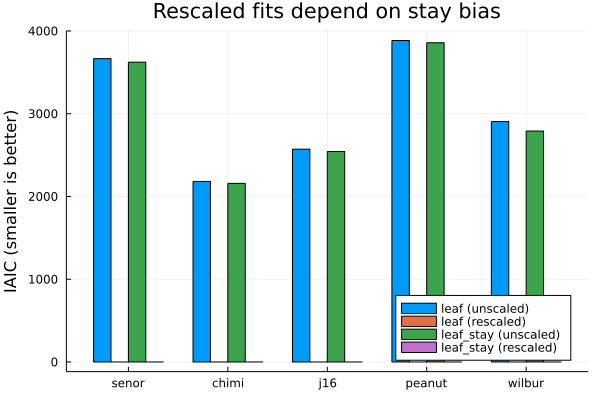

In [12]:
fns = vcat(fns_hmm[[1,4]])
(results1, aics1) = load_hmm_results(animals, fns; rewscaled=false)
(results2, aics2) = load_hmm_results(animals, fns; rewscaled=true)
aics = hcat(aics1[:,1], aics2[:,1], aics1[:,2], aics2[:,2])
labels = ["leaf (unscaled)" "leaf (rescaled)" "leaf_stay (unscaled)" "leaf_stay (rescaled)"]
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = labels,
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="Rescaled fits depend on stay bias",
)

We observe that all four give similar fits, *except* for rescaling without also introducing a stay bias, which leads to much worse performance

## γ2 and retainbelief

Next, let's take a look at a few independent choices and their effect on model fit:
- `γ2`: Weight applied to the leaf we're *leaving* on the current stem, versus leaf we're going to
- `retainbelief`: Do we allow a fraction of our belief state (contingency belief) to persist between sessions?

On the left, we see IAIC values for baseline (from here onwards baseline includes `stay_bias`), on the right bias terms

On the right, we see the improvement (decrease) in IAIC for the latter 2 versus baseline

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_wilbur.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_wilbur.jld2
Missing: .

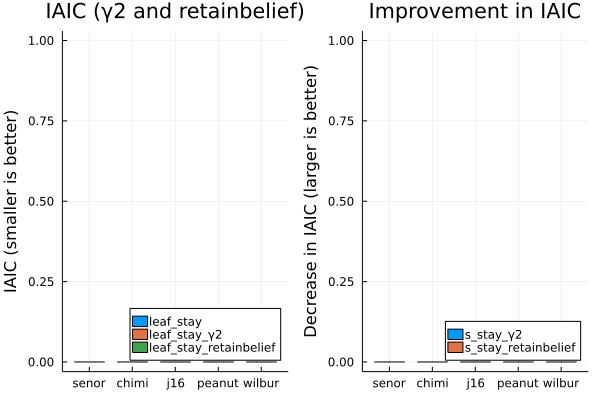

In [13]:
fns = vcat(fns_hmm[4], fns_hmm_stay[[1,2]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (γ2 and retainbelief)",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=:bottomright,
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2)

Results:
- `γ2` leads to a small decrease in IAIC in 3 animals (tossup?)
- `retainbelief` leads to worse model fits

Out of curiosity, what are the values being fit for `retainbelief` and `γ2`?

In [14]:
fns = vcat(fns_hmm_stay[[2]])
(results, aics) = load_hmm_results(animals, fns)
peanut_retain = results["peanut", "hmm_leaf_stay_retainbelief"].x[:,6]
peanut_retain = 0.5.+0.5.*erf.(peanut_retain ./ sqrt(2))
chimi_retain = results["chimi", "hmm_leaf_stay_retainbelief"].x[:,6]
chimi_retain = 0.5.+0.5.*erf.(chimi_retain ./ sqrt(2))
j16_retain = results["j16", "hmm_leaf_stay_retainbelief"].x[:,6]
j16_retain = 0.5.+0.5.*erf.(j16_retain ./ sqrt(2))
senor_retain = results["senor", "hmm_leaf_stay_retainbelief"].x[:,6]
senor_retain = 0.5.+0.5.*erf.(senor_retain ./ sqrt(2))
wilbur_retain = results["wilbur", "hmm_leaf_stay_retainbelief"].x[:,6]
wilbur_retain = 0.5.+0.5.*erf.(wilbur_retain ./ sqrt(2))
p = plot(legend=:right)
plot!(peanut_retain, label="peanut")
plot!(wilbur_retain, label="wilbur")
plot!(j16_retain, label="j16")
plot!(chimi_retain, label="chimi")
plot!(senor_retain, label="senor")
xlabel!("Day")
ylabel!("retain_belief")
title!("Per-Day retainbelief fits")

Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_retainbelief_rewscaled_wilbur.jld2


LoadError: KeyError: key ("peanut", "hmm_leaf_stay_retainbelief") not found

So intriguingly, we *do* see a steady decrease, with high values at the start for a number of animals

May be necessary to model as time-varying parameter?

In [15]:
println("retainbelief p-values:")
HTML([results[animal, "hmm_leaf_stay_retainbelief"].pvalues[6] for animal in animals])

retainbelief p-values:


LoadError: KeyError: key ("senor", "hmm_leaf_stay_retainbelief") not found

Not significant in 2 animals, couldn't estimate in 2

In [16]:
fns = vcat(fns_hmm_stay[[1]])
(results, aics) = load_hmm_results(animals, fns)
peanut_retain = results["peanut", "hmm_leaf_stay_γ2"].x[:,6]
peanut_retain = 0.5.+0.5.*erf.(peanut_retain ./ sqrt(2))
chimi_retain = results["chimi", "hmm_leaf_stay_γ2"].x[:,6]
chimi_retain = 0.5.+0.5.*erf.(chimi_retain ./ sqrt(2))
j16_retain = results["j16", "hmm_leaf_stay_γ2"].x[:,6]
j16_retain = 0.5.+0.5.*erf.(j16_retain ./ sqrt(2))
senor_retain = results["senor", "hmm_leaf_stay_γ2"].x[:,6]
senor_retain = 0.5.+0.5.*erf.(senor_retain ./ sqrt(2))
wilbur_retain = results["wilbur", "hmm_leaf_stay_γ2"].x[:,6]
wilbur_retain = 0.5.+0.5.*erf.(wilbur_retain ./ sqrt(2))
p = plot()
plot!(peanut_retain, label="peanut")
plot!(wilbur_retain, label="wilbur")
plot!(j16_retain, label="j16")
plot!(chimi_retain, label="chimi")
plot!(senor_retain, label="senor")
xlabel!("Day")
ylabel!("γ2")
title!("Per-Day γ2 fits")

Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_γ2_rewscaled_wilbur.jld2


LoadError: KeyError: key ("peanut", "hmm_leaf_stay_γ2") not found

Fits are for a consistently low value.

So mostly weighting the upcoming leaf

Significant?

In [17]:
println("γ2 p-values:")
HTML([results[animal, "hmm_leaf_stay_γ2"].pvalues[6] for animal in animals])

γ2 p-values:


LoadError: KeyError: key ("senor", "hmm_leaf_stay_γ2") not found

The fits are also clearly significant for the 4/5 animals where `emerrors` successfully ran

However, values are for difference from 0 (which is a 50/50 weighting) so perhaps not the test that we really want

## Stem Biases

### Turn Bias
Similar to the stay bias, we can include an offset for a particular turn direction (essentially, a bias for left/right)

So if we're at stem 1, our softmax is based on

\begin{align}
& \beta_\text{stay} \text{Qstem}_1 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_2 + \text{turnbias} \\
& \beta_\text{go} \text{Qstem}_3
\end{align}

Or if we're at stem 2, we instead add the same bias to stem 3

\begin{align}
& \beta_\text{go} \text{Qstem}_1 \\
& \beta_\text{stay} \text{Qstem}_2 + \text{staybias}\\
& \beta_\text{go} \text{Qstem}_3 + \text{turnbias} 
\end{align}

### Spatial Bias
We can also make this slightly more flexible, by varying the turn bias depending on our current stem.

So if we're at stem 1, we use one bias

\begin{align}
& \beta_\text{stay} \text{Qstem}_1 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_2 + \text{spatialbias}_2 \\
& \beta_\text{go} \text{Qstem}_3
\end{align}

Or if we're at stem 2, we add a different bias to stem 3

\begin{align}
& \beta_\text{go} \text{Qstem}_1 \\
& \beta_\text{stay} \text{Qstem}_2 + \text{staybias} \\
& \beta_\text{go} \text{Qstem}_3 + \text{spatialbias}_3
\end{align}

This approach adds three free parameters (one for each stem) versus one parameter for the simpler turn bias

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_spatial_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_spatial_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_spatial_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_spatial_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_wilbur.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_rewscaled_wilbur.jld2
Missing: ../results/

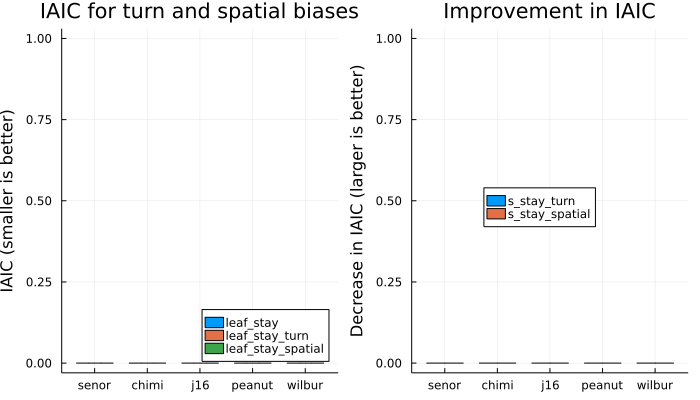

In [18]:
fns = vcat(fns_hmm[[4]], fns_hmm_stay[[3,4]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][5:end] for x in fns]),
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC for turn and spatial biases",
)

p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.35, 0.5),
    ylabel="Decrease in IAIC (larger is better)",
    title="Improvement in IAIC",
)
plot(p1, p2, size=(700, 400))

We observe an increase in model fit for either of these options, though in all rats besides senor, the single-parameter turn bias leads to a better fit

## Leaf Biases

### Leaf Turn Bias

Similar to our stem bias, we can bias leaf decisions (after a stem switch) either left/right with a single parameter

\begin{align}
& \beta_\text{leaf} \text{Qleaf}_1 + \text{leaf\_turn\_bias}\\
& \beta_\text{leaf} \text{Qleaf}_2
\end{align}

### Leaf Spatial Bias

We can again also parameterize this based on the stem:

That is, $\text{leaf\_spatial\_bias}$ has three parameters, one for each stem we're choosing between leaves on

Below, we're comparing to the `stay` model as baseline, and adding either 1-param or 3-param stem biases

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafturn_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafspatial_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafturn_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafspatial_rewscaled_chimi.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafturn_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafspatial_rewscaled_j16.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafturn_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafspatial_rewscaled_peanut.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_wilbur.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_leafturn_rewsca

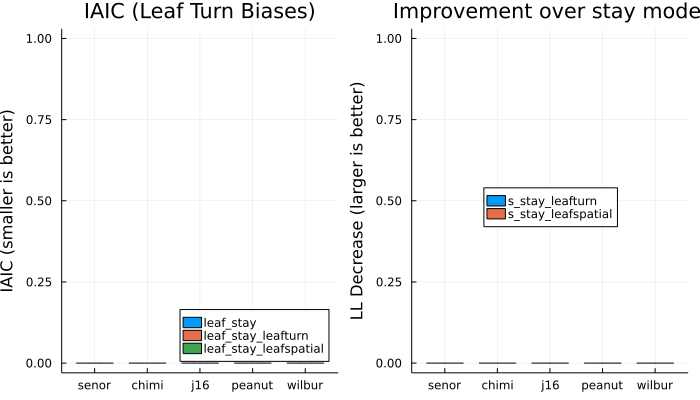

In [19]:
fns = vcat(fns_hmm[[4]], fns_hmm_stay[[5,6]])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (Leaf Turn Biases)",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.35,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(700, 400))

Addition of either bias leads to a huge model fit improvement - here though, the three-parameter version consistently provides a better fit

# Stem + Leaf Biases

Let's now compare the full set of 1 and 3 parameter biases for both stem and leaf choice

In [20]:
fns = vcat(fns_hmm[4], fns_hmm_stay[7:10])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC (Stem and Leaf Biases)",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][10:end] for x in fns[2:end]]),
    legend=(0.28,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400), left_margin = 5mm)

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2
Missing: ../results/hmm_biases/hmm_leaf_stay_turn_leafturn_rewscaled_senor.jld2


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

Adding a single-parameter leaf turn bias has mixed effects, in some cases leading to worse model fit

Adding the three-parameter leaf bias, however, provides a huge improvement for all animals except wilbur, where we see marginal difference

In combination, a 1-parameter stem bias + 3-parameter leaf bias seems to provide the best fit

## Best-fitting model full results

In [21]:
animal = animals[1]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay[8]])
HTML(show_results(results[animal, fns_hmm_stay[8][1]]; transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))]]))

senor


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

In [22]:
animal = animals[2]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay[8]])
HTML(show_results(results[animal, fns_hmm_stay[8][1]]; transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))]]))

chimi


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_chimi.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_chimi" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

In [23]:
animal = animals[3]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay[8]])
HTML(show_results(results[animal, fns_hmm_stay[8][1]]; transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))]]))

j16


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_j16.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_j16" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39

In [24]:
animal = animals[4]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay[8]])
HTML(show_results(results[animal, fns_hmm_stay[8][1]]; transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))]]))

peanut


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_peanut.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_peanut" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/

In [25]:
animal = animals[5]
println(animal)
(results, aics) = load_hmm_results([animal], [fns_hmm_stay[8]])
HTML(show_results(results[animal, fns_hmm_stay[8][1]]; transforms=[["volatility", x->0.5+0.5*erf(x / sqrt(2))]]))

wilbur


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_wilbur.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_wilbur" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/

# Revisiting γ2 with full model fit

In [26]:
fns = vcat(fns_hmm[4],fns_hmm_stay[8],fns_hmm_stay_γ2[4])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][10:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][1:end] for x in fns[2:end]]),
    legend=(0.28,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

In [27]:
fns = vcat(fns_hmm[4],fns_hmm_stay[8],fns_hmm_stay_γ2[4])
(results, aics) = load_hmm_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][10:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][1:end] for x in fns[2:end]]),
    legend=(0.28,0.5),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
)
plot(p1, p2, size=(1200, 400))

Missing: ../results/hmm_biases/hmm_leaf_stay_rewscaled_senor.jld2


Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

# Per-Day Parameter Estimates

In [28]:
fns = [fns_hmm_stay[8]]
(results, aics) = load_hmm_results(animals, fns)
x = zeros(5,16,9)
x[1,1:11,:] = results[(animals[1], "hmm_leaf_stay_turn_leafspatial")].x
x[2,1:16,:] = results[(animals[2], "hmm_leaf_stay_turn_leafspatial")].x
x[3,1:8,:] = results[(animals[3], "hmm_leaf_stay_turn_leafspatial")].x
x[4,1:8,:] = results[(animals[4], "hmm_leaf_stay_turn_leafspatial")].x
x[5,1:8,:] = results[(animals[5], "hmm_leaf_stay_turn_leafspatial")].x
# [results[(animal, "hmm_leaf_stay_turn_leafspatial")].x for animal in animals]
varnames = results[(animals[1], "hmm_leaf_stay_turn_leafspatial")].varnames

p1 = plot(0.5.+0.5.*erf.(x[[1,3,4,5], :, 1]' ./ sqrt(2)),
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[1],
    legend=nothing,
)
xlims!(1,11)

p2 = plot(x[[1,3,4,5], :, 2]',
    labels=nothing,
    title=varnames[2],
)
xlims!(1,11)

p3 = plot(x[[1,3,4,5], :, 3]',
    labels=nothing,
    title=varnames[3],
)
xlims!(1,11)

p4 = plot(x[[1,3,4,5], :, 4]',
    labels=nothing,
    title=varnames[4],
)
xlims!(1,11)

p5 = plot(x[[1,3,4,5], :, 5]',
    labels=permutedims(animals[[1,3,4,5]]),
    title=varnames[5],
    legend=(0.4,0.4),
)
xlims!(1,11)
println("AICS:")
println(aics)
plot(p1, p2, p3, p4, p5)

Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[

## Leaf Biases

In [29]:
fns = [fns_hmm_stay[8]]
(results, aics) = load_hmm_results(animals, fns)
animal = animals[1]
p1 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=(0.5, 0.8))
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[2]
p2 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[3]
p3 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[4]
p4 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

animal = animals[5]
p5 = plot(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,6:8], labels=["leaf1" "leaf2" "leaf3"], legend=nothing)
plot!(results[(animal, "hmm_leaf_stay_turn_leafspatial")].x[:,5], style=:dash, labels="stem")
title!(animal)

plot(p1, p2, p3, p4, p5)

Error encountered while load File{DataFormat{:JLD2}, String}("../results/hmm_biases/hmm_leaf_stay_turn_leafspatial_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "hmm_leaf_stay_turn_leafspatial_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[